# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample; and
- find a documented dataset, audit every feature, and interpret its quantitative and categorical distributions.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

The [U.S. Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data](https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ) contains 611,735 reported domestic flight records for May 2026. Completed, non-diverted flights with recorded values for all five selected features were eligible for this lab. Canceled flights, diverted flights, and records missing any selected feature were excluded before the sample was drawn.

The dataset is a reproducible random sample of 5,000 eligible flights. Each observation represents one completed, non-diverted domestic flight in that sample. Because incomplete records were removed before sampling, finding no missing values in the dataset does not mean that the original BTS data had no missing values. Conclusions from this sample describe the eligible flights and should not automatically be generalized to canceled or diverted flights.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [1]:
import pandas as pd

flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")

Display the first five rows of the DataFrame.


In [2]:
flights.head()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [3]:
flights.tail()


,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [4]:
flights.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   airline                5000 non-null   object
 1   origin_city            5000 non-null   object
 2   destination_city       5000 non-null   object
 3   distance_miles         5000 non-null   int64 
 4   arrival_delay_minutes  5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


**How many observations are in the DataFrame?**

Your answer: 5000


Count the missing values in every feature.


In [5]:
flights.isnull().sum()

airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type, feature type, and number of missing values for each feature. Use `.info()` and `.isnull().sum()`; enter 0 when no values are missing.**

| Feature | Pandas data type | Feature type | Number of missing values |
| --- | --- | --- | ---: |
| `airline` | object | Categorical | 0 |
| `origin_city` | object | Categorical | 0 |
| `destination_city` | object | Categorical | 0 |
| `distance_miles` | int64 | Quantitative | 0 |
| `arrival_delay_minutes` | int64 | Quantitative | 0 |


## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [6]:
destination_counts = flights["destination_city"].value_counts()
destination_counts

destination_city
Chicago, IL                       296
Atlanta, GA                       222
Dallas/Fort Worth, TX             210
Denver, CO                        209
Washington, DC                    165
                                 ... 
Gunnison, CO                        1
Allentown/Bethlehem/Easton, PA      1
Idaho Falls, ID                     1
Jamestown, ND                       1
Yuma, AZ                            1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


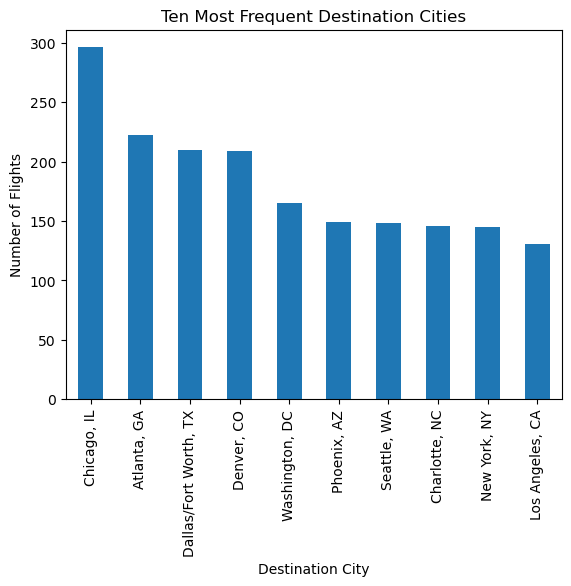

In [7]:
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind="bar")
plt.title("Ten Most Frequent Destination Cities")
plt.xlabel("Destination City")
plt.ylabel("Number of Flights")
plt.show()

**Which destination city is most common in the sample?**

Your answer: Chicago, IL


## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


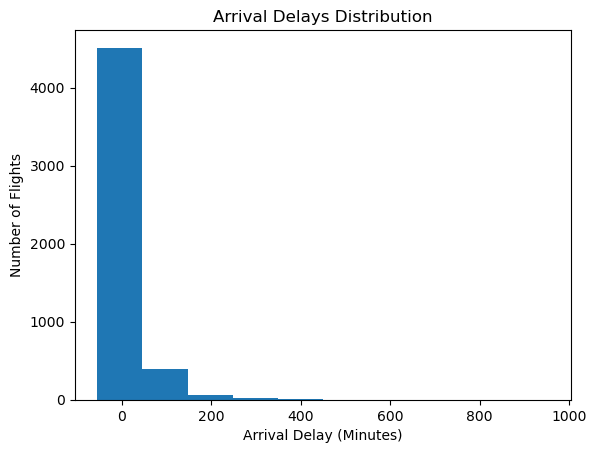

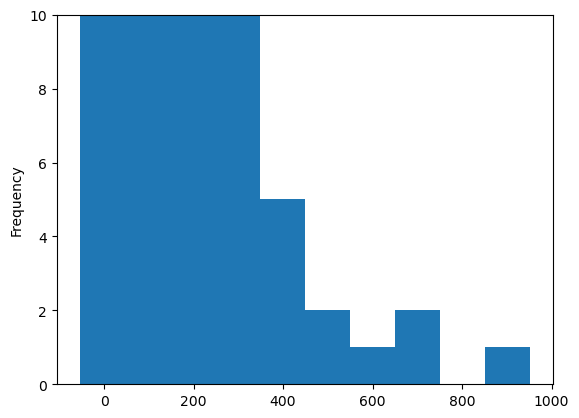

In [8]:
flights["arrival_delay_minutes"].plot(kind="hist")
plt.title("Arrival Delays Distribution")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")
plt.show()

#Zoomed in
flights["arrival_delay_minutes"].plot(kind="hist")
plt.ylim(0, 10)
plt.show()

**Approximately what arrival-delay value appears most common?**

Your answer: 0


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer: about -50 to about +950


**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer: Right skewed


Display a numerical summary of `arrival_delay_minutes`.


In [9]:
flights["arrival_delay_minutes"].describe()

count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [10]:
flights["arrival_delay_minutes"].mode()

0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: It was 8 minutes off from my estimate of 0


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer: Very close, mine being -50 and 950, but the real being -55 and 953


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: The mean is greater than the median, 6.1 > -6


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: it is skewed right because of the extremely late flights that are over 900 minutes


## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


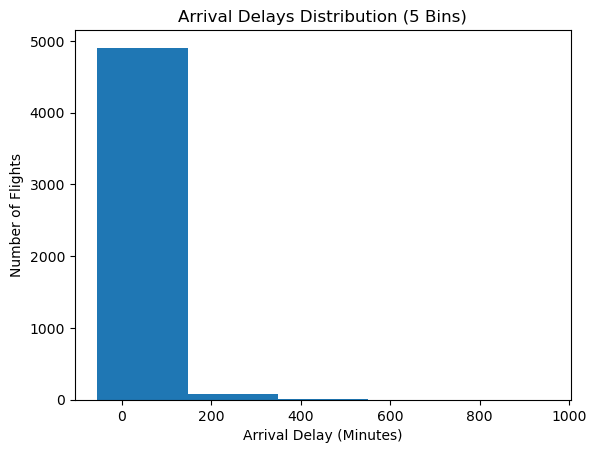

In [11]:
flights["arrival_delay_minutes"].plot(kind="hist", bins=5)
plt.title("Arrival Delays Distribution (5 Bins)")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")
plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


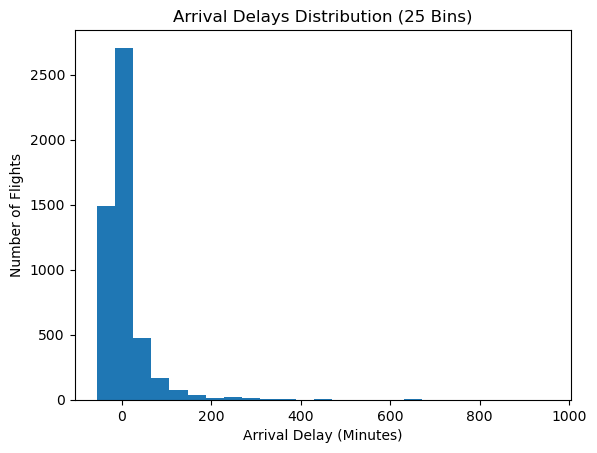

In [12]:
flights["arrival_delay_minutes"].plot(kind="hist", bins=25)
plt.title("Arrival Delays Distribution (25 Bins)")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")
plt.show()

**What changed when the number of bins was reduced to 5?**

Your answer: Each bar covered about 200 minutes, so most flights were in the first bar


**What changed when the number of bins was increased to 25?**

Your answer: Each bar covered about 40 minutes, so there is more detail, showing the peak more clearly


**Which bin setting communicates the distribution most clearly?**

Your answer: 25 is most clear as it shows how the right tail tapers off, and most values cluster near 0


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


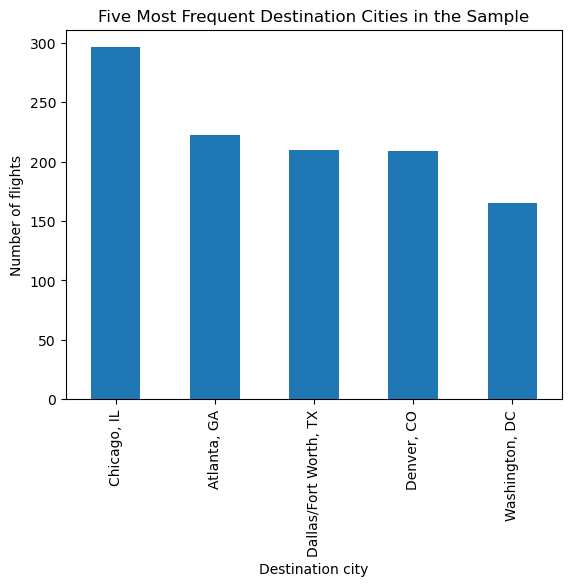

In [13]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


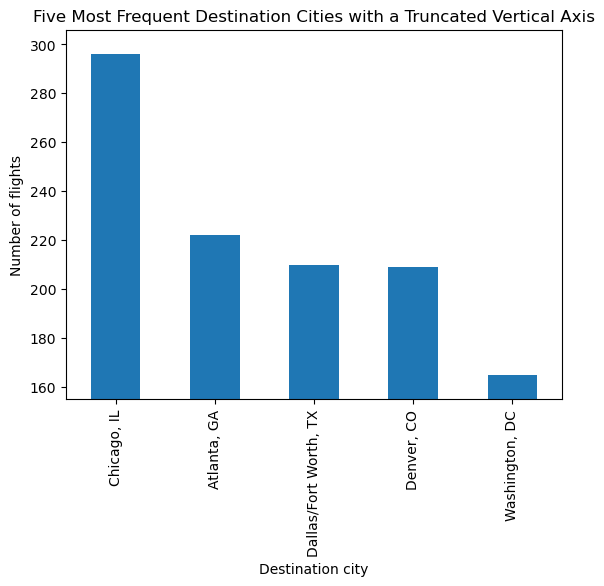

In [14]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: Truncated starts at 155 which makes the differences look much bigger


**Which chart communicates the counts more honestly?**

Your answer: The first one that starts at 0 since the heights are proportional to the counts


## Is this sample representative?

Review the dataset description at the top of the lab before answering these questions.


**What time period is represented by the source data?**

Your answer: May 2026


**Which flights were eligible to be included in the sample?**

Your answer: Completed, non-diverted flights from May 2026 with recorded values for all 5 selected features


**Which flights and records were excluded before the sample was selected?**

Your answer: Canceled flights, diverted flights, and records missing a value for any of the five selected features


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer: No as records with missing values were removed before the sample was drawn, so the original BTS data could still have missing data


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: Canceled and diverted flights were excluded before sampling, so none are in the data, and the sample only describes completed and non-diverted flights


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. Use the question and number of categories to justify your choice.


**Which chart would you use to show the frequency of each airline?**

Your answer: Bar chart with 13 airlines in the sample. Too many slices for pie charts.


**Which chart would you use to show what proportion of sampled flights were early, on time, and delayed? Use arrival delays below 0, equal to 0, and above 0 minutes, respectively.**

Your answer: Pie chart with 3 categories. Shows each category clearly.


**Which chart would you use to show the distribution of flight distances?**

Your answer: Histogram since distance is quantitative and it groups them into ranges


## Explore a dataset of your own

Apply the same inspection and visualization process to a different dataset that interests you.

### 1. Find and describe your dataset

Start with [Kaggle Datasets](https://www.kaggle.com/datasets), the [UCI Machine Learning Repository](https://archive.ics.uci.edu/), or [Data.gov](https://catalog.data.gov/). You can also search a city or state open-data portal. Search for a topic you enjoy, such as sports, music, animals, transportation, or the environment.

Choose a manageable CSV file with a data dictionary (or equivalent feature documentation), at least one quantitative feature, and at least one categorical feature with a manageable number of categories. Use a different dataset from the flights and penguins already used in class. Save the file in this notebook's `data` folder.

Read the data dictionary before choosing your features. In a short paragraph, describe the dataset's subject, what one row represents, and its time period and geographic coverage if documented. Include its title, publisher or creator, a direct link to the dataset, and a link to the data dictionary. State when information is not documented instead of guessing.


**Dataset description and source links:**

Your answer:

This dataset, *Full Pokemons and Moves Datasets*, was created by Thiago Amancio and published on Kaggle under a CC0: Public Domain license. I used the `metadata_pokemon.csv` file, which contains base statistics, physical measurements, and types for Pokémon from the main video game series. Each row represents one Pokémon species, identified by its National Pokédex number (`id`), covering numbers 1 (Bulbasaur) through 998 (Baxcalibur). The file includes 998 Pokémon and 12 features. The dataset was last updated on Kaggle on September 28, 2023. The original source of the data, the time period it was collected, and any geographic coverage are not documented on the dataset page. Geographic coverage does not apply because the data describes fictional video game creatures.

- Dataset: [Full Pokemons and Moves Datasets on Kaggle](https://www.kaggle.com/datasets/thiagoamancio/full-pokemons-and-moves-datasets)
- Data dictionary: the "About Dataset" section of the same Kaggle page, under "Pokémon Dataset Key Columns"


### 2. Load the data and describe every feature

Load your CSV into a new DataFrame with a descriptive name ending in `_df`, such as `movies_df`, `weather_df`, or `animals_df`. Choose a name that describes your dataset and use it consistently throughout your analysis. Display its first five rows, shape, `.info()`, and `.isnull().sum()` to inspect its features, storage types, and missing values. Use a relative path so your notebook can run on another computer.


In [15]:
pokemon_df = pd.read_csv("data/metadata_pokemon.csv")

display(pokemon_df.head())
print(pokemon_df.shape)
pokemon_df.info()
pokemon_df.isnull().sum()

,name,id,hp,attack,defense,special_attack,special_defense,speed,height,weight,type_1,type_2
0,Bulbasaur,1,45,49,49,65,65,45,7,69,Grass,Poison
1,Ivysaur,2,60,62,63,80,80,60,10,130,Grass,Poison
2,Venusaur,3,80,82,83,100,100,80,20,1000,Grass,Poison
3,Charmander,4,39,52,43,60,50,65,6,85,Fire,NaN
4,Charmeleon,5,58,64,58,80,65,80,11,190,Fire,NaN


(998, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             998 non-null    object
 1   id               998 non-null    int64 
 2   hp               998 non-null    int64 
 3   attack           998 non-null    int64 
 4   defense          998 non-null    int64 
 5   special_attack   998 non-null    int64 
 6   special_defense  998 non-null    int64 
 7   speed            998 non-null    int64 
 8   height           998 non-null    int64 
 9   weight           998 non-null    int64 
 10  type_1           998 non-null    object
 11  type_2           502 non-null    object
dtypes: int64(9), object(3)
memory usage: 93.7+ KB


name                 0
id                   0
hp                   0
attack               0
defense              0
special_attack       0
special_defense      0
speed                0
height               0
weight               0
type_1               0
type_2             496
dtype: int64

Complete the table below with **one row for every feature** in your dataset. Add as many rows as needed. Use the data dictionary to summarize what each feature means, including units or category-code meanings where relevant.

- **Data type:** quantitative or categorical; identify identifiers and date/time features explicitly when appropriate. A numeric identifier is not a quantitative measurement.
- **Data storage type:** the actual Pandas dtype shown by `.info()` or `.dtypes`, such as `int64`, `float64`, `object`, `str`, or `datetime64[ns]`.
- **Missing values:** the number reported for that feature, including 0 when there are none. Count missing values before removing records. If the dictionary defines special missing codes, such as -999 or "Unknown", explain how you handle those codes and make sure the counts reflect that decision.


| Feature | Description from the data dictionary (including units/codes) | Data type | Data storage type | Number of missing values |
| --- | --- | --- | --- | ---: |
| `name` | Pokémon name | Categorical (identifier; each Pokémon has a unique name) | object | 0 |
| `id` | Unique identification number for the Pokémon (National Pokédex number) | Identifier | int64 | 0 |
| `hp` | Pokémon's Hit Points (HP) | Quantitative | int64 | 0 |
| `attack` | Pokémon's Attack value | Quantitative | int64 | 0 |
| `defense` | Pokémon's Defense value | Quantitative | int64 | 0 |
| `special_attack` | Pokémon's Special Attack value | Quantitative | int64 | 0 |
| `special_defense` | Pokémon's Special Defense value | Quantitative | int64 | 0 |
| `speed` | Pokémon's Speed | Quantitative | int64 | 0 |
| `height` | Pokémon's height (in decimeters) | Quantitative | int64 | 0 |
| `weight` | Pokémon's weight (listed in grams; see note below) | Quantitative | int64 | 0 |
| `type_1` | Pokémon's primary type | Categorical | object | 0 |
| `type_2` | Pokémon's secondary type (if applicable) | Categorical | object | 496 |

**Missing-value codes or other data preparation, if applicable:**

Your answer: The missing values are all in type_2 with 496 blanks. Those all mean that the Pokémon only has 1 type and does not have a secondary typing. The missing data is deliberate, so I kept those rows and didn't fill them in. Claude caught that the weight seems to be in hectograms (10ths of a kilogram) as Bulbasaur's weight it 69, which would match its real weight of 6.9kg rather than 69g. I did not change the values though.


### 3. Visualize one quantitative feature

Choose one quantitative measurement and create an appropriate visualization of its distribution, such as a histogram. Include a descriptive title, a horizontal-axis label naming the feature and its units, and a vertical-axis label explaining what the heights represent. Explain any excluded missing values or other filtering. Do not use an ID number as your quantitative feature.


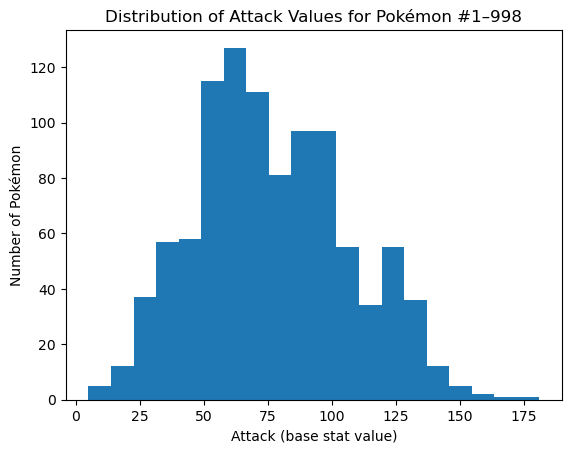

In [16]:
pokemon_df["attack"].plot(kind="hist", bins=20)
plt.title("Distribution of Attack Values for Pokémon #1–998")
plt.xlabel("Attack (base stat value)")
plt.ylabel("Number of Pokémon")
plt.show()

**Which feature did you choose, and why is this chart appropriate?**

Your answer: Attack, as it is a quantitative feature and the histogram would group the values into ranges that show the shape, center, and spread well. And all 998 Pokémon have an attack value.

**In at least one complete sentence, describe what the figure tells you about this feature.** Refer to a visible pattern such as typical values, range, shape, or unusual observations, using values and units where possible. Describe the observations in your dataset without assuming they represent a larger population.

Your interpretation: Most Pokémon have an attack value between 50 and 100 with most of those between 60 and 65. Values range from 5 to 181. The distribution is skewed right slightly with some having 150 and above attack stat. The median is 75 and the mean is between 75 and 80.


### 4. Visualize one categorical feature

Choose a categorical feature and create an appropriate visualization of its distribution. A bar chart of category counts is a good choice; use `.value_counts()` to obtain numeric bar heights from text labels. Include a descriptive title and labels identifying the categories and counts or percentages on the axes. If you choose a pie chart for a small number of categories, label the slices and their shares instead of axes. Explain any excluded missing values or categories, and identify the denominator if you use percentages.


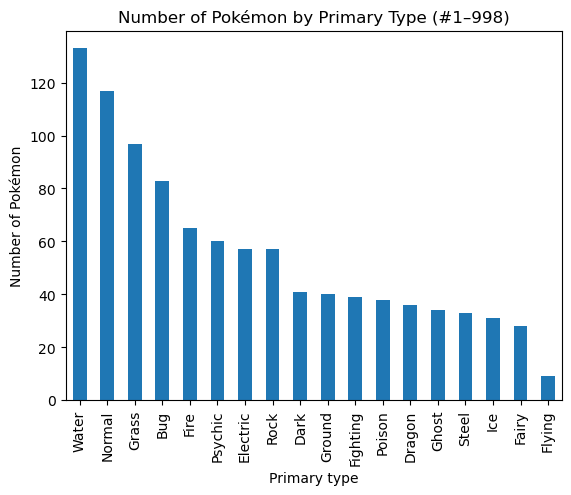

In [17]:
type_counts = pokemon_df["type_1"].value_counts()

type_counts.plot(kind="bar")
plt.title("Number of Pokémon by Primary Type (#1–998)")
plt.xlabel("Primary type")
plt.ylabel("Number of Pokémon")
plt.show()

**Which feature did you choose, and why is this chart appropriate?**

Your answer: Primary typing, type_1, as each Pokémon has a primary type, it's a categorical feature with 18 categories, and no missing values. The bar chart makes it easy to compare the counts from each category.

**In at least one complete sentence, describe what the figure tells you about this feature.** Identify a meaningful pattern, such as the most or least common category or a difference in counts or shares. Support the interpretation with evidence visible in your figure.

Your interpretation: Water is the most common primary typing with about 130, followed by normal (~120) and then grass (~100). Flying is the least common with about 10. Most fall between about 30 and 70.


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used:
- What I asked it to help with:
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why:

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response:

- **Tool used:** Claude (Claude Code). I used it alongside Google and help from my dad with syntax.
- **What I asked it to help with:**
  - Writing the dataset description and source-link paragraph for my Pokémon dataset
  - Filling in the feature table (descriptions, data types, storage types)
  - Reviewing my finished lab against the actual data before submitting
  - Writing this response
- **One suggestion I checked against my code, chart, or output:**
  - Claude said the data dictionary lists weight in grams, but the values match hectograms. Bulbasaur's weight is 69, and its real weight is 6.9 kg. I confirmed this in the first rows of my DataFrame.
  - I also checked the dataset paragraph against the Kaggle page (title, creator, license, last-updated date, data dictionary) and against my loaded data (998 rows, IDs 1–998).
  - I checked the feature table against my own `.info()` and `.isnull().sum()` output.
  - In the review, Claude pointed out that I had left the observation-count question blank and that my eligible-flights answer was incomplete. I checked both against the `.info()` output and the dataset description.
- **What I accepted, modified, or rejected—and why:**
  - I accepted the hectogram observation and documented it in my notes. I rejected converting the values, though, and kept the originals so the data matches the source.
  - From the review, I accepted the fixes to the blank answer and the eligible-flights answer, plus the typo corrections, because they matched my output and the dataset documentation.

## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The chosen dataset and its data dictionary are linked and described.
- The feature table includes a description, data type, storage type, and missing-value count for every feature.
- One quantitative and one categorical feature have appropriate labeled visualizations and at least one sentence of interpretation each.
- The chosen CSV is included in the `data` folder with the submitted notebook, and relative paths work.
- The AI-use reflection is complete and honest.
